<a href="https://colab.research.google.com/github/Karimmaniyar44/Credit_Card_Analytics_Dashboard./blob/main/Mileage_Prediction_Regression_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Mileage Prediction - Regression Analysis**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('https://raw.githubusercontent.com/YBIFoundation/Dataset/refs/heads/main/MPG.csv')

In [3]:
df.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino


In [4]:
df.nunique()

,0
mpg,129
cylinders,5
displacement,82
horsepower,93
weight,351
acceleration,95
model_year,13
origin,3
name,305


**Data Pre-Processing**

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    392 non-null    float64
 4   weight        398 non-null    int64  
 5   acceleration  398 non-null    float64
 6   model_year    398 non-null    int64  
 7   origin        398 non-null    object 
 8   name          398 non-null    object 
dtypes: float64(4), int64(3), object(2)
memory usage: 28.1+ KB


In [6]:
df.describe()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year
count,398.000000,398.000000,398.000000,392.000000,398.000000,398.000000,398.000000
mean,23.514573,5.454774,193.425879,104.469388,2970.424623,15.568090,76.010050
std,7.815984,1.701004,104.269838,38.491160,846.841774,2.757689,3.697627
min,9.000000,3.000000,68.000000,46.000000,1613.000000,8.000000,70.000000
25%,17.500000,4.000000,104.250000,75.000000,2223.750000,13.825000,73.000000
50%,23.000000,4.000000,148.500000,93.500000,2803.500000,15.500000,76.000000
75%,29.000000,8.000000,262.000000,126.000000,3608.000000,17.175000,79.000000
max,46.600000,8.000000,455.000000,230.000000,5140.000000,24.800000,82.000000


In [10]:
df.corr(numeric_only=True)

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year
mpg,1.000000,-0.775396,-0.804203,-0.778427,-0.831741,0.420289,0.579267
cylinders,-0.775396,1.000000,0.950721,0.842983,0.896017,-0.505419,-0.348746
displacement,-0.804203,0.950721,1.000000,0.897257,0.932824,-0.543684,-0.370164
horsepower,-0.778427,0.842983,0.897257,1.000000,0.864538,-0.689196,-0.416361
weight,-0.831741,0.896017,0.932824,0.864538,1.000000,-0.417457,-0.306564
acceleration,0.420289,-0.505419,-0.543684,-0.689196,-0.417457,1.000000,0.288137
model_year,0.579267,-0.348746,-0.370164,-0.416361,-0.306564,0.288137,1.000000


**Remove Missing Values**

In [11]:
df = df.dropna()

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 392 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           392 non-null    float64
 1   cylinders     392 non-null    int64  
 2   displacement  392 non-null    float64
 3   horsepower    392 non-null    float64
 4   weight        392 non-null    int64  
 5   acceleration  392 non-null    float64
 6   model_year    392 non-null    int64  
 7   origin        392 non-null    object 
 8   name          392 non-null    object 
dtypes: float64(4), int64(3), object(2)
memory usage: 30.6+ KB


**Data Visualization**

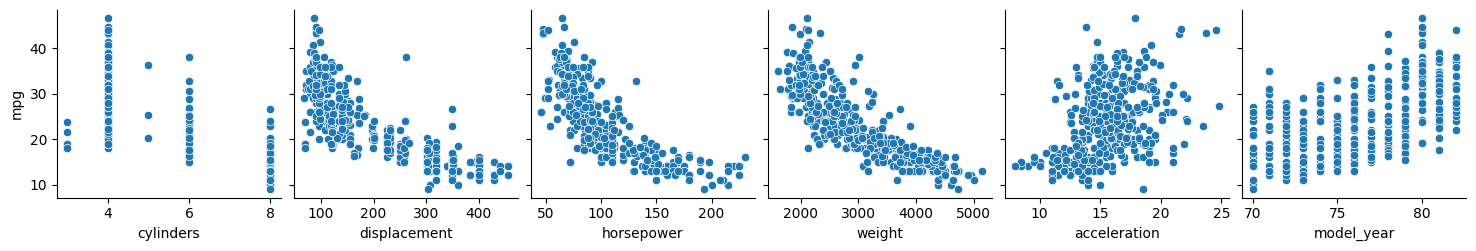

In [20]:
sns.pairplot(df, x_vars=['cylinders', 'displacement', 'horsepower', 'weight', 'acceleration', 'model_year'], y_vars='mpg')

<Axes: xlabel='displacement', ylabel='mpg'>

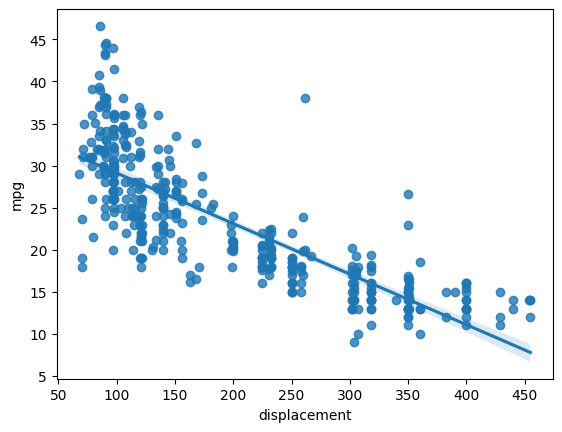

In [21]:
sns.regplot(x = 'displacement', y = 'mpg', data = df)

**Define Target Variable y and Feature X**

In [22]:
df.columns

Index(['mpg', 'cylinders', 'displacement', 'horsepower', 'weight',
       'acceleration', 'model_year', 'origin', 'name'],
      dtype='object')

In [23]:
y = df['mpg']

In [24]:
y.shape

(392,)

In [27]:
X = df[['displacement', 'horsepower', 'weight', 'acceleration', 'model_year']]

In [28]:
X.shape

(392, 5)

In [29]:
X

,displacement,horsepower,weight,acceleration,model_year
0,307.0,130.0,3504,12.0,70
1,350.0,165.0,3693,11.5,70
2,318.0,150.0,3436,11.0,70
3,304.0,150.0,3433,12.0,70
4,302.0,140.0,3449,10.5,70
...,...,...,...,...,...
393,140.0,86.0,2790,15.6,82
394,97.0,52.0,2130,24.6,82
395,135.0,84.0,2295,11.6,82
396,120.0,79.0,2625,18.6,82


**Scaling Data**

In [30]:
from sklearn.preprocessing import StandardScaler

In [31]:
ss = StandardScaler()

In [32]:
X = ss.fit_transform(X)

In [33]:
X

array([[ 1.07728956,  0.66413273,  0.62054034, -1.285258  , -1.62531533],
       [ 1.48873169,  1.57459447,  0.84333403, -1.46672362, -1.62531533],
       [ 1.1825422 ,  1.18439658,  0.54038176, -1.64818924, -1.62531533],
       ...,
       [-0.56847897, -0.53247413, -0.80463202, -1.4304305 ,  1.63640964],
       [-0.7120053 , -0.66254009, -0.41562716,  1.11008813,  1.63640964],
       [-0.72157372, -0.58450051, -0.30364091,  1.40043312,  1.63640964]])

In [35]:
pd.DataFrame(X).describe()

,0,1,2,3,4
count,3.920000e+02,3.920000e+02,3.920000e+02,3.920000e+02,3.920000e+02
mean,-7.250436e-17,-1.812609e-16,-1.812609e-17,4.350262e-16,-1.160070e-15
std,1.001278e+00,1.001278e+00,1.001278e+00,1.001278e+00,1.001278e+00
min,-1.209563e+00,-1.520975e+00,-1.608575e+00,-2.736983e+00,-1.625315e+00
25%,-8.555316e-01,-7.665929e-01,-8.868535e-01,-6.410551e-01,-8.098841e-01
50%,-4.153842e-01,-2.853488e-01,-2.052109e-01,-1.499869e-02,5.547151e-03
75%,7.782764e-01,5.600800e-01,7.510927e-01,5.384714e-01,8.209784e-01
max,2.493416e+00,3.265452e+00,2.549061e+00,3.360262e+00,1.636410e+00


**After Standardization Mean is Zero and Standard Deviation is One**

# **Train Test Split Data**

In [36]:
from sklearn.model_selection import train_test_split

In [37]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [38]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((274, 5), (118, 5), (274,), (118,))

# **Linear Regression Model**

In [39]:
from sklearn.linear_model import LinearRegression

In [40]:
lr = LinearRegression()

In [41]:
lr.fit(X_train, y_train)

LinearRegression()

In [42]:
lr.intercept_

np.float64(23.586015797554047)

In [43]:
lr.coef_

array([-0.11374584, -0.35604614, -5.41962665,  0.17899785,  2.68369425])

**Mileage  = 23.58 - 0.11 (displacement) - 0.35 (horsepower) -5.41 (weight) + 0.17 (acceleration) + 2.68 (model_year) + error**

# **Predict Test Data**

In [44]:
y_pred = lr.predict(X_test)

In [45]:
y_pred

array([26.31642996, 26.21895873, 33.16321554, 27.24051243, 29.41014589,
       29.29086692,  7.59504563, 29.4345043 , 21.12584116, 29.41619588,
       12.18811   , 23.91132379, 16.27846284, 28.43320659, 22.08399743,
       30.86385601, 21.49321756, 31.70637   , 28.02569018, 29.77253298,
       20.22898171, 34.57304765, 34.06959898, 15.2720119 , 29.09379776,
       26.20126073, 21.17399151, 16.9648988 , 28.97960515, 24.16723572,
       12.8836965 , 23.77584509, 21.47659658, 29.97924639, 11.04080061,
       34.757423  , 11.11776276, 26.55043884, 11.85655317,  7.45918255,
       13.0659818 , 28.08137337, 34.7147151 , 26.75438054, 11.43599908,
        8.59894909, 17.95453832, 31.59061475, 25.71325994, 30.59460444,
       11.68536645, 25.32611697, 24.70302585, 33.36679128, 28.72324903,
       18.00043776, 21.05894612, 23.30794762, 23.38722702, 24.81864856,
        7.11005187, 23.14150232, 27.31684433, 23.33123871, 28.12040797,
       28.83183494, 26.90801203, 29.85215561, 22.45945033,  9.03

**Model Accuracy**

In [46]:
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error,r2_score

In [47]:
mean_absolute_error(y_test, y_pred)

2.5503387977667904

In [48]:
mean_absolute_percentage_error(y_test, y_pred)

0.12512395939932075

In [49]:
r2_score(y_test, y_pred)

0.8066725937555242

# **Polynomial Regression**

In [50]:
from sklearn.preprocessing import PolynomialFeatures

In [51]:
poly = PolynomialFeatures(degree=2, interaction_only=True ,include_bias=False)

In [52]:
X_train2 = poly.fit_transform(X_train)

In [53]:
X_test2 = poly.fit_transform(X_test)

In [54]:
lr.fit(X_train2, y_train)

LinearRegression()

In [55]:
lr.intercept_

np.float64(21.06619658771326)

In [56]:
lr.coef_

array([-0.85828577, -3.41152261, -4.04301148, -0.9043744 ,  2.68171902,
       -0.555762  ,  1.52848784, -0.32853921,  1.25986833,  0.89716734,
       -0.86930793, -1.40178089,  0.68929032, -0.42634041,  0.36163938])

In [57]:
y_pred_poly = lr.predict(X_test2)

# **Model Accuracy**

In [58]:
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error,r2_score

In [59]:
mean_absolute_error(y_test, y_pred_poly)

2.0321490082457863

In [60]:
mean_absolute_percentage_error(y_test, y_pred_poly)

0.09326046775498813

In [61]:
r2_score(y_test, y_pred_poly)

0.8539737013892983